# PIV analysis over a user-defined time window

Takes one PIVlab run, cuts out a time window and a region of interest (ROI), and produces:

1. a **movie** of the velocity field over the window (quiver on top of speed in colour),
2. the **mean kinetic energy over the ROI** for every frame, `<Ek>_ROI (t)`,
3. the **ROI-averaged amplitude spectrum of Ek** — the FFT is taken of the `Ek` time series at
   *every grid point* in the ROI, and the resulting spectra are then averaged over the ROI,
4. a saved 2-panel figure (`Ek` vs `t`, and the spectrum) whose title carries the time window.

Everything below is self-contained: only numpy / scipy / matplotlib, reading the `.mat` directly.

**Edit the `USER SETTINGS` cell, then run all.**

In [1]:
import os
import shutil

import numpy as np
import scipy.io as sio

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.animation import FFMpegWriter

# %matplotlib inline
# %matplotlib qt    
%matplotlib widget

from piv_postprocessing_lib import (PTS_ROI, XSCALE, YSCALE, calibrate, create_mask,
                        fft_axis_limits, parse_run_name, read_acquisition_log,
                        region_tag)

# A Jupyter kernel does not always inherit the shell PATH, so point matplotlib at ffmpeg explicitly.
matplotlib.rcParams['animation.ffmpeg_path'] = shutil.which('ffmpeg') or '/usr/local/bin/ffmpeg'

plt.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
})

## 1. User settings

In [2]:
# ----------------------------------------------------------------------
# USER SETTINGS -- normally the only cell you need to touch
# ----------------------------------------------------------------------

# Run folder: must hold PIVlab_results_uncalibrated.mat and acquisition_log.txt
dataDir = ('/Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/'
           'CylinderExperimentsGMA/k6_TopBottom/frot0.50Hz_flib1.500Hz_dphi16deg_SS1/')

# --- Time window to analyse [s], counted from the first PIV field --------
t_start = 8.0
t_end   = 12.0

# --- Region of interest, in calibrated coordinates [m] -------------------
# Two opposite corners [(x_a, z_a), (x_b, z_b)]; the order does not matter.
REGION = 'ROI'                       # 'ROI' (crop to PTS_ROI) or 'FULL' (whole field)
# PTS_ROI (ROI corners) and XSCALE/YSCALE (calibration) come from piv_postprocessing_lib,
# same as the other notebooks -- edit them there.

# --- Movie ---------------------------------------------------------------
make_movie       = True
movie_fps        = 20                # playback rate of the .mp4
quiver_skip      = 3                 # draw every n-th vector in each direction
movie_max_frames = 600               # if the window holds more, frames are strided
mag_clim         = None              # None -> autoscale from the window, or e.g. (0.0, 0.01)

# --- Spectrum ------------------------------------------------------------
use_hann = True                      # Hann window before the FFT; recommended for short windows

# --- Output --------------------------------------------------------------
outDir   = os.path.join(dataDir, 'PostProcessing')
save_npz = True

## 2. Helper functions

In [3]:
# load_piv_run reads the RAW pixel fields (no flip); piv_postprocessing_lib.calibrate then
# converts to metres/(m/s) with z up. This is deliberately split -- piv_postprocessing_lib's
# load_piv returns already-flipped calibrated-ready arrays, a different contract.
def load_piv_run(mat_path):
    """Read a PIVlab batch result file.

    Returns the pixel grid x_px, y_px (2-D; it is stored per frame but is constant
    in time, so only the first slice is kept) and the validated displacements
    u_px, v_px (3-D, px per laser pulse, image convention with v positive downward).

    Only the needed variables are read, so the ~100 MB correlation_map stays on disk.
    """
    mat = sio.loadmat(mat_path, variable_names=['x', 'y', 'u_filt', 'v_filt'])
    x_px = mat['x'][:, :, 0].astype(float)
    y_px = mat['y'][:, :, 0].astype(float)
    u_px = mat['u_filt'].astype(float)
    v_px = mat['v_filt'].astype(float)
    return x_px, y_px, u_px, v_px


def kinetic_energy(u, w):
    """Specific kinetic energy 0.5*(u^2 + w^2) [m^2/s^2], per grid point and frame."""
    return 0.5 * (u ** 2 + w ** 2)


def amplitude_spectrum(sig, dt, use_hann=True):
    """Single-sided amplitude spectrum along the last axis.

    sig may carry any leading shape, so the FFT is taken independently at every point.
    The mean is removed first, otherwise the zero-frequency peak swamps everything else.
    Returns freq [Hz] and the amplitudes, in the same units as sig.
    """
    n = sig.shape[-1]
    s = sig - np.nanmean(sig, axis=-1, keepdims=True)

    if use_hann:
        win = np.hanning(n)
        cg = win.mean()               # coherent gain: undoes the amplitude loss of the window
        s = s * win
    else:
        cg = 1.0

    amp = np.abs(np.fft.rfft(s, axis=-1)) * (2.0 / (n * cg))
    amp[..., 0] /= 2.0                # DC has no mirrored twin to fold in
    if n % 2 == 0:
        amp[..., -1] /= 2.0           # neither does Nyquist
    return np.fft.rfftfreq(n, d=dt), amp

## 3. Load the run and calibrate

In [4]:
PIV_file = os.path.join(dataDir, 'PIVlab_results_uncalibrated.mat')
log_file = os.path.join(dataDir, 'acquisition_log.txt')
run_name = os.path.basename(os.path.normpath(dataDir))

meta     = read_acquisition_log(log_file)
cam_fps  = float(meta['cam_fps'])
dt_pulse = float(meta['pulse_sep']) * 1e-6      # s, laser pulse separation

# Images are correlated in pairs (1+2, 3+4, ...): one PIV field per two camera
# frames, so the field sampling rate is half the camera rate.
fps = cam_fps / 2.0
dt  = 1.0 / fps

x_px, y_px, u_px, v_px = load_piv_run(PIV_file)
x, z, u, w = calibrate(x_px, y_px, u_px, v_px, XSCALE, YSCALE, dt_pulse)

nframes = u.shape[2]
t = np.arange(nframes) * dt

print('run           :', run_name)
print('grid          : {} x {} vectors'.format(*x.shape))
print('frames        :', nframes)
print('cam_fps       : {:g} Hz  ->  PIV field rate {:g} Hz (dt = {:.2f} ms)'.format(cam_fps, fps, dt * 1e3))
print('pulse_sep     : {:.0f} us'.format(dt_pulse * 1e6))
print('record length : {:.2f} s'.format(t[-1]))
print('x range       : {:.1f} .. {:.1f} mm'.format(x.min() * 1e3, x.max() * 1e3))
print('z range       : {:.1f} .. {:.1f} mm'.format(z.min() * 1e3, z.max() * 1e3))

run           : frot0.50Hz_flib1.500Hz_dphi16deg_SS1
grid          : 75 x 120 vectors
frames        : 1500
cam_fps       : 160 Hz  ->  PIV field rate 80 Hz (dt = 12.50 ms)
pulse_sep     : 4800 us
record length : 18.74 s
x range       : 2.1 .. 236.7 mm
z range       : 0.0 .. 145.9 mm


## 4. Cut out the time window and the ROI

In [5]:
# --- time window -> frames -----------------------------------------------
if t_end <= t_start:
    raise ValueError('t_end ({:g}) must be greater than t_start ({:g})'.format(t_end, t_start))
if t_start < t[0] or t_end > t[-1]:
    raise ValueError('window [{:g}, {:g}] s falls outside the record [0, {:.2f}] s'
                     .format(t_start, t_end, t[-1]))

sel = (t >= t_start) & (t <= t_end)
if sel.sum() < 4:
    raise ValueError('window holds only {} frames; widen it'.format(sel.sum()))

t_w = t[sel]
u_w = u[:, :, sel]
w_w = w[:, :, sel]

# --- ROI (region = 'ROI' crops to PTS_ROI, 'FULL' keeps the whole field) --
region = region_tag(REGION)          # validate: 'ROI' or 'FULL'
if region == 'FULL':
    inside    = np.ones(x.shape, dtype=bool)
    roi_label = 'full field'
else:
    inside = create_mask(x, z, PTS_ROI)
    if not inside.any():
        raise ValueError('PTS_ROI selects no grid point -- are the corners in metres?')
    roi_label = 'ROI'

window_tag   = 't{:g}-{:g}s_{}'.format(t_start, t_end, region)   # names movie, figure, npz
window_title = '{:g}-{:g} s ({})'.format(t_start, t_end, region)

print('window        : {:.3f} .. {:.3f} s  ({} frames, {:.2f} s long)'
      .format(t_w[0], t_w[-1], t_w.size, t_w[-1] - t_w[0]))
print('spectrum      : resolution ~{:.3f} Hz, Nyquist {:g} Hz'
      .format(1.0 / (t_w[-1] - t_w[0]), fps / 2))
print('{:<14}: {} of {} grid points'.format(roi_label, int(inside.sum()), inside.size))

window        : 8.000 .. 12.000 s  (321 frames, 4.00 s long)
spectrum      : resolution ~0.250 Hz, Nyquist 40 Hz
ROI           : 5607 of 9000 grid points


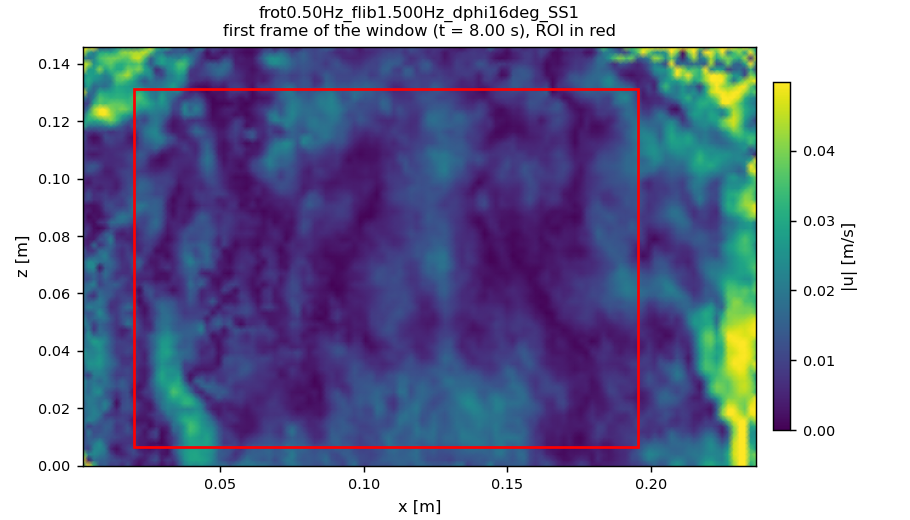

In [6]:
# Speed over the window, and the colour scale shared by the preview and the movie.
mag_w = np.sqrt(u_w ** 2 + w_w ** 2)
vmin, vmax = (0.0, float(np.nanpercentile(mag_w, 99))) if mag_clim is None else mag_clim

fig, ax = plt.subplots(figsize=(7, 4), dpi=130)
pcm = ax.pcolormesh(x, z, mag_w[:, :, 0], cmap='viridis', shading='gouraud', vmin=vmin, vmax=vmax)
if region != 'FULL':
    (xa, za), (xb, zb) = PTS_ROI
    ax.add_patch(Rectangle((min(xa, xb), min(za, zb)), abs(xb - xa), abs(zb - za),
                           fill=False, ec='red', lw=1.5))
ax.set_aspect('equal')
ax.set_xlabel('x [m]')
ax.set_ylabel('z [m]')
ax.set_title('{}\nfirst frame of the window (t = {:.2f} s), ROI in red'.format(run_name, t_w[0]))
fig.colorbar(pcm, ax=ax, shrink=0.8, pad=0.02).set_label('|u| [m/s]')
fig.tight_layout()
plt.show()

## 5. Movie of the velocity field over the window

Speed in colour with the vectors on top. The quiver scale is set by the first frame and then
held fixed, so arrow lengths stay comparable from frame to frame.

In [7]:
os.makedirs(outDir, exist_ok=True)
movie_path = os.path.join(outDir, 'velocity_field_{}.mp4'.format(window_tag))

if make_movie:
    stride = max(1, int(np.ceil(t_w.size / movie_max_frames)))
    frames = np.arange(0, t_w.size, stride)
    if stride > 1:
        print('window holds {} frames (> movie_max_frames = {}): keeping every {}th -> {} frames'
              .format(t_w.size, movie_max_frames, stride, frames.size))

    sk = quiver_skip
    fig, ax = plt.subplots(figsize=(7, 4.2), dpi=150)
    pcm = ax.pcolormesh(x, z, mag_w[:, :, 0], cmap='viridis', shading='gouraud',
                        vmin=vmin, vmax=vmax)
    qv = ax.quiver(x[::sk, ::sk], z[::sk, ::sk], u_w[::sk, ::sk, 0], w_w[::sk, ::sk, 0],
                   color='w', pivot='mid', width=0.002)
    if region != 'FULL':
        (xa, za), (xb, zb) = PTS_ROI
        ax.add_patch(Rectangle((min(xa, xb), min(za, zb)), abs(xb - xa), abs(zb - za),
                               fill=False, ec='red', lw=1.2))
    ax.set_aspect('equal')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('z [m]')
    fig.colorbar(pcm, ax=ax, shrink=0.8, pad=0.02).set_label('|u| [m/s]')
    ttl = ax.set_title('')
    fig.tight_layout()

    writer = FFMpegWriter(fps=movie_fps, bitrate=4000, metadata={'title': run_name})
    with writer.saving(fig, movie_path, dpi=150):
        for k in frames:
            pcm.set_array(mag_w[:, :, k])
            qv.set_UVC(u_w[::sk, ::sk, k], w_w[::sk, ::sk, k])
            ttl.set_text('{}   |   window {}\nt = {:.3f} s'.format(run_name, window_title, t_w[k]))
            writer.grab_frame()
    plt.close(fig)
    print('movie  ->', movie_path)
else:
    print('make_movie is False, skipping the movie')

movie  -> /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot0.50Hz_flib1.500Hz_dphi16deg_SS1/PostProcessing/velocity_field_t8-12s_ROI.mp4


## 6. Kinetic energy and its spectrum over the ROI

`Ek_t` is the ROI average of `0.5*(u^2+w^2)` for each frame.

For the spectrum, the FFT is taken of the `Ek` time series **at each ROI grid point** and the
spectra are then averaged over the ROI. This keeps fluctuations that are not in phase across the
ROI, which a spatial average before the FFT would cancel.

In [8]:
ek = kinetic_energy(u_w, w_w)                 # (nz, nx, nt) [m^2/s^2]

ek_pts = ek[inside]                           # (n_roi_points, nt): ROI points only
Ek_t   = np.nanmean(ek_pts, axis=0)           # ROI-mean kinetic energy per frame

freq, amp_pts = amplitude_spectrum(ek_pts, dt, use_hann=use_hann)
amp_roi = np.nanmean(amp_pts, axis=0)         # spectra averaged over the ROI points

k_peak = 1 + int(np.argmax(amp_roi[1:]))      # skip the (removed) DC bin
print('<Ek> over ROI and window : {:.4e} m2/s2'.format(Ek_t.mean()))
print('std of Ek over the window: {:.4e} m2/s2'.format(Ek_t.std()))
print('peak of the ROI-averaged spectrum: {:.3f} Hz'.format(freq[k_peak]))

<Ek> over ROI and window : 9.5636e-05 m2/s2
std of Ek over the window: 3.2028e-05 m2/s2
peak of the ROI-averaged spectrum: 0.249 Hz


## 7. Figure: Ek versus time and its spectrum

figure -> /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot0.50Hz_flib1.500Hz_dphi16deg_SS1/PostProcessing/KineticEnergy_Ek_and_FFT_t8-12s_ROI.png


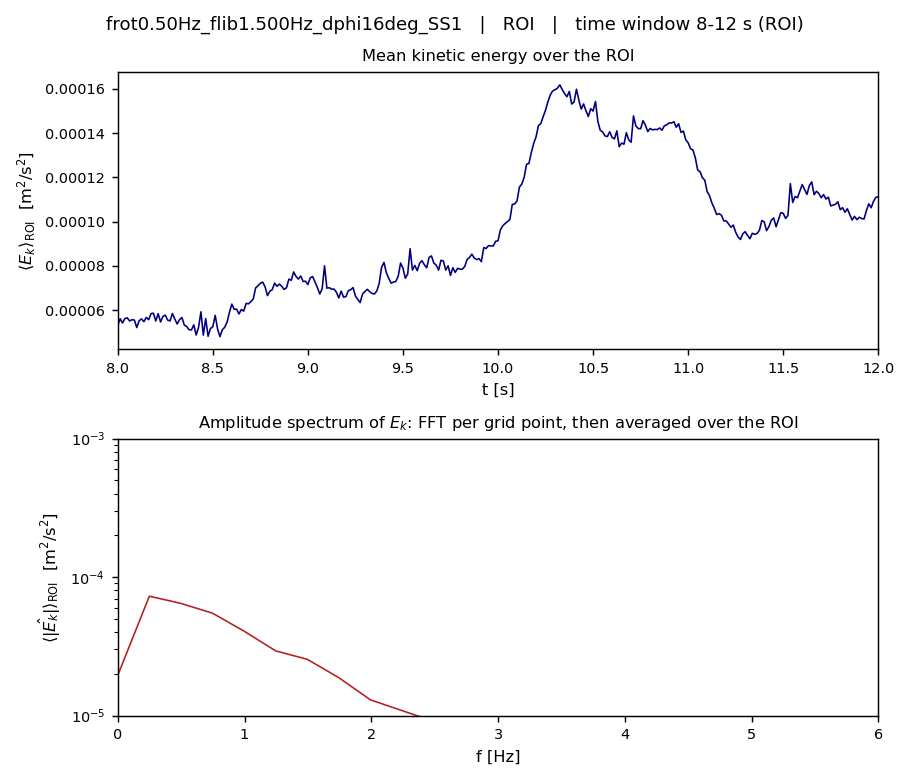

In [9]:
frot_hz, flib_hz, _ = parse_run_name(run_name)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), dpi=130)
fig.suptitle('{}   |   {}   |   time window {}'.format(run_name, roi_label, window_title),
             fontsize=10)

ax1.plot(t_w, Ek_t, color='navy', lw=0.9)
ax1.set_xlim(t_w[0], t_w[-1])
ax1.set_xlabel('t [s]')
ax1.set_ylabel(r'$\langle E_k \rangle_{\mathrm{ROI}}$  [m$^2$/s$^2$]')
ax1.set_title('Mean kinetic energy over the ROI')

ax2.plot(freq, amp_roi, color='firebrick', lw=0.9)
# Frequency axis to [0, max(4*frot,4*flib)]; y to decade bounds.
_xmax, _ymin, _ymax = fft_axis_limits(freq, amp_roi, frot_hz, flib_hz)
ax2.set_xlim(0, _xmax)
ax2.set_yscale('log')
if _ymin and _ymax:
    ax2.set_ylim(_ymin, _ymax)
ax2.set_xlabel('f [Hz]')
ax2.set_ylabel(r'$\langle |\hat{E_k}| \rangle_{\mathrm{ROI}}$  [m$^2$/s$^2$]')
ax2.set_title('Amplitude spectrum of $E_k$: FFT per grid point, then averaged over the ROI')

fig.tight_layout()
fig_path = os.path.join(outDir, 'KineticEnergy_Ek_and_FFT_{}.png'.format(window_tag))
fig.savefig(fig_path, dpi=200, bbox_inches='tight')
print('figure ->', fig_path)
plt.show()

In [10]:
if save_npz:
    npz_path = os.path.join(outDir, 'KineticEnergy_Ek_and_FFT_{}.npz'.format(window_tag))
    np.savez(npz_path,
             t=t_w, Ek_t=Ek_t, freq=freq, amp_roi=amp_roi,
             t_window=np.array([t_start, t_end]),
             pts_ROI=np.array(PTS_ROI, dtype=float),
             region=region, n_roi_points=int(inside.sum()),
             dt=dt, fps=fps, xscale=XSCALE, yscale=YSCALE,
             dt_pulse=dt_pulse, use_hann=use_hann, run=run_name)
    print('data   ->', npz_path)

data   -> /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot0.50Hz_flib1.500Hz_dphi16deg_SS1/PostProcessing/KineticEnergy_Ek_and_FFT_t8-12s_ROI.npz
